In [1]:
import pyjack
import numpy


In [2]:
numpy.random.seed(42)

my_data = numpy.random.randn(100,10)*0.3+4

obs = pyjack.observable(description='My Bootstrap Observable')
obs.create(my_data, method='bootstrap', binsize=5, n_resamples=2000, seed=42)
print(obs)
print('resampling method =', obs.resampling_method)


pyjack(4.001(22), 4.000(25), 3.986(30), 4.032(23), 4.022(30), 3.991(33), 3.985(29), 4.010(27), 4.008(26), 4.018(28), description=My Bootstrap Observable)
resampling method = bootstrap


In [3]:
# Arithmetic operations casted for observables

squared = obs ** 2
exponential = pyjack.exp(obs)
summed = obs @ numpy.ones(my_data.shape[1])

print(squared)
print(exponential)
print(summed)


pyjack(16.01(18), 16.00(20), 15.89(24), 16.26(19), 16.18(24), 15.93(26), 15.88(23), 16.08(22), 16.07(21), 16.14(23), description=My Bootstrap Observable)
pyjack(54.6(12), 54.6(13), 53.9(16), 56.4(13), 55.9(16), 54.1(17), 53.8(15), 55.2(15), 55.1(14), 55.6(16), description=My Bootstrap Observable)
pyjack(40.054(88), description=My Bootstrap Observable)


In [4]:
# Slicing and item assignments are also allowed

sliced = obs[2:5]
obs[2:5] = 2.*sliced
sliced2 = obs[2:5]

print(sliced, sliced2)


pyjack(3.986(30), 4.032(23), 4.022(30), description=My Bootstrap Observable) pyjack(7.972(61), 8.064(47), 8.045(60), description=My Bootstrap Observable)


In [5]:
# Confidence intervals

normal_ci = obs.confidence_interval(level=0.68, method='normal')
percentile_ci = obs.confidence_interval(level=0.68, method='percentile')

print('normal interval shapes:', normal_ci[0].shape, normal_ci[1].shape)
print('percentile interval shapes:', percentile_ci[0].shape, percentile_ci[1].shape)
print('first observable normal interval:', normal_ci[0][0], normal_ci[1][0])
print('first observable percentile interval:', percentile_ci[0][0], percentile_ci[1][0])


normal interval shapes: (10,) (10,)
percentile interval shapes: (10,) (10,)
first observable normal interval: 3.978208485092262 4.023145195898177
first observable percentile interval: 3.977469711573401 4.022545269844747


[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 10 iterations. Exiting successfully
[jackfit.fit] chi2obs = 8.11648564446639
[jackfit.fit] chi2exp = 7.4231851053032685 +- 0.23474172425795184
[jackfit.fit] p-value = 0.3868 +- 0.004870415597750307
pyjack(4.008(21), 0.0037(36), description=Best parameters of fit)


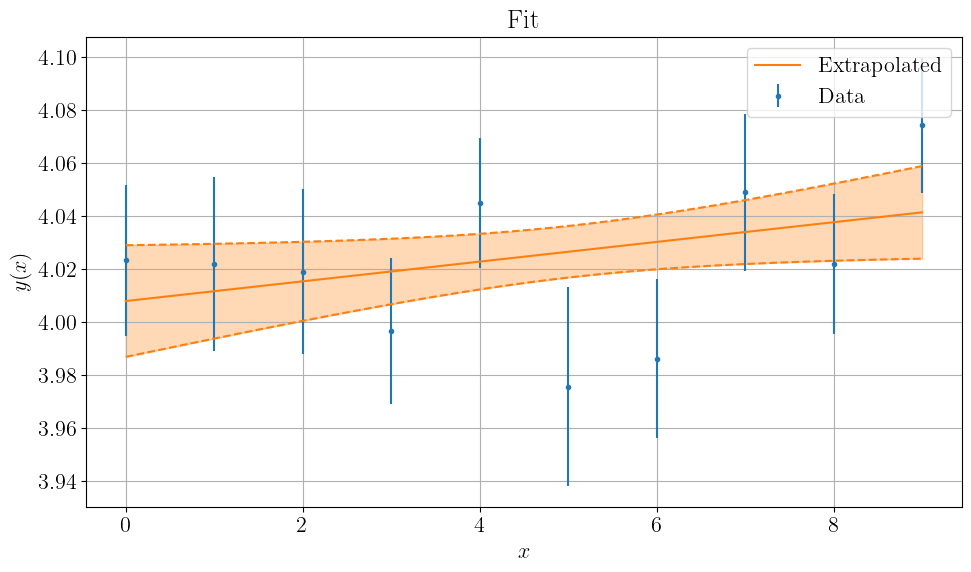

In [6]:
# Possibility to perform fits

import matplotlib.pyplot as plt
data = numpy.random.randn(100,10)*0.3+4
obs = pyjack.observable()
obs.create(data, method='bootstrap', binsize=5, n_resamples=2000, seed=123)
fitfunc = 'params0+params1*x'
initial_guess = [3,0]
W = 'diag'
fit1 = pyjack.jackfit(fitfunc,W,initial_guess)
fit1.fit(numpy.arange(obs.data.shape[1]),obs,max_iter=1000,tol=1e-8,num_samples=10000)
print(fit1.params)
fit1.plot()


[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 2 iterations. Exiting successfully
[jackfit.fit] chi2obs = 11.080113220736232
[jackfit.fit] chi2exp = 7.969396582495231 +- 0.252014447778469
[jackfit.fit] p-value = 0.1987 +- 0.003990416437207304
pyjack(4.0058(55), -0.0017(10), description=Best parameters of fit)


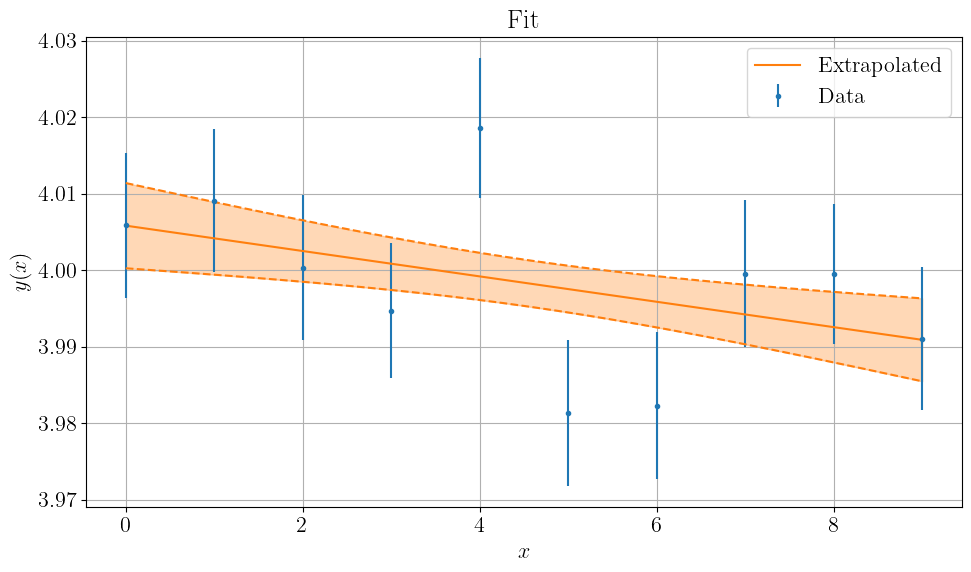

In [7]:
# Increase statistics

new_data = numpy.random.randn(1000,10)*0.3+4

obs.increase_statistics(new_data)

fit1 = pyjack.jackfit(fitfunc,W,initial_guess)
fit1.fit(numpy.arange(obs.data.shape[1]),obs,max_iter=1000,tol=1e-8,num_samples=10000)
print(fit1.params)
fit1.plot()


In [8]:
# Do operations directly on observables

pyjack.mean(obs,axis=0)


pyjack(3.9982(30), description=None)

In [9]:
obs


pyjack(4.0058(94), 4.0091(93), 4.0003(94), 3.9947(87), 4.0185(91), 3.9813(95), 3.9823(96), 3.9995(95), 3.9995(91), 3.9910(93), description=None)

In [10]:
pyjack.roll(obs,axis=0,shift=-2)


pyjack(4.0003(94), 3.9947(87), 4.0185(91), 3.9813(95), 3.9823(96), 3.9995(95), 3.9995(91), 3.9910(93), 4.0058(94), 4.0091(93), description=None)

In [11]:
# Scalar observables can be created as well
mean = 2
cov = 0.003**2
obs2 = pyjack.observable(description='Scalar observable')
obs2.create_from_cov(mean,cov)

obs2


pyjack(2.0000(30), description=Scalar observable)

In [12]:
# When an operation involves an observable created from mean and covariance,
# bootstrap replicas are generated for the scalar observable before computing
# the replicas for the derived observable

obs * obs2


pyjack(8.012(18), 8.018(18), 8.001(18), 7.989(17), 8.037(18), 7.963(19), 7.965(19), 7.999(19), 7.999(18), 7.982(18), description=None)

In [13]:
obs * 2


pyjack(8.012(18), 8.018(18), 8.001(18), 7.989(17), 8.037(18), 7.963(19), 7.965(19), 7.999(19), 7.999(18), 7.982(18), description=None)